In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from transformers import AutoTokenizer, AutoModel
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, accuracy_score,precision_score, recall_score,auc
import joblib

import warnings
warnings.filterwarnings("ignore")
for d in ["../data","../results/figures","../results/tables","../models"]:
    os.makedirs(d, exist_ok=True)


In [4]:
def get_embeddings(sequences, tokenizer, model, batch_size=32):
    """
    Return mean-pooled ESM-2 embeddings for a list of sequences.
    Shape: (N, hidden_dim).  Padding tokens are excluded from the mean.
    """
    all_embs = []
    for i in range(0, len(sequences), batch_size):
        batch  = sequences[i : i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt",
                           padding=True, truncation=True, max_length=128)
        with torch.no_grad():
            out = model(**inputs)
        mask   = inputs["attention_mask"].unsqueeze(-1).float()  # (B, L, 1)
        summed = (out.last_hidden_state * mask).sum(dim=1)        # (B, D)
        counts = mask.sum(dim=1).clamp(min=1e-9)                  # (B, 1)
        all_embs.append((summed / counts).numpy())
        if (i // batch_size) % 20 == 0:
            print(f"  {min(i+batch_size, len(sequences))}/{len(sequences)}")
    return np.vstack(all_embs)

In [6]:
df = pd.read_csv("../data/sequences.csv")
df

,sequence,label,seq_len
0,MKNYSKNATHLITVLLFSFVVILLIIPSKCEAVSNDMQPLEARSAD...,1,77
1,MKKVLFLVVALASFAFGADGEQIKAFSVVAAGIGLGVAALGGAIGM...,0,100
2,MASGSGPGAAASANLNAVRETMDVLLEISRILNTGLDMETLSICVR...,0,78
3,LECNKLVPIAHKTCPEGKNLCYKMFMVSTSTVPVKRGCIDVCPKDS...,0,60
4,MVKRKANHVINGMNDAKSQGKGAGYIENDQLVLTEAERQNNKKRKTNQ,0,48
...,...,...,...
4913,MANSNNKTNAQQVRKQNQQSASGQGQFGTEFASETNVQQVRKQNQQ...,0,82
4914,MNYLILISFALLVITGVESARDAYIAKPHNCVYECFDAFSSYCNGV...,1,86
4915,GVIPCGESCVFIPCISAAIGCSCKNKVCYRN,0,31
4916,MAQDLSEKELLRMEVEQLKKEVKNPRDLISKTGKEIKDYVEAQAGT...,0,69


In [16]:
MODEL_NAME = "facebook/esm2_t6_8M_UR50D"   # 8M params — CPU-feasible (~0.05s/seq)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm2 = AutoModel.from_pretrained(MODEL_NAME)
esm2.eval()

print(f"Model  : {MODEL_NAME}")
print(f"Params : {sum(p.numel() for p in esm2.parameters())/1e6:.1f}M")

X = get_embeddings(df["sequence"].tolist(), tokenizer, esm2)
y = df["label"].values
print(f"Done  shape={X.shape}")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model  : facebook/esm2_t6_8M_UR50D
Params : 7.8M
  32/4918
  672/4918
  1312/4918
  1952/4918
  2592/4918
  3232/4918
  3872/4918
  4512/4918
Done  shape=(4918, 320)


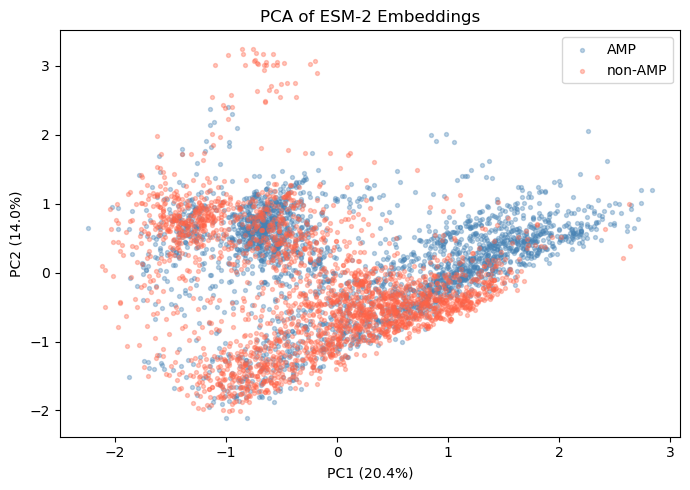

In [12]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
for label, name, color in [(1,"AMP","steelblue"),(0,"non-AMP","tomato")]:
    m = y == label
    plt.scatter(X_2d[m,0], X_2d[m,1], s=8, alpha=0.35, label=name, color=color)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of ESM-2 Embeddings"); plt.legend()
plt.tight_layout()
plt.savefig("../results/figures/01_pca.png", dpi=150)
plt.show()

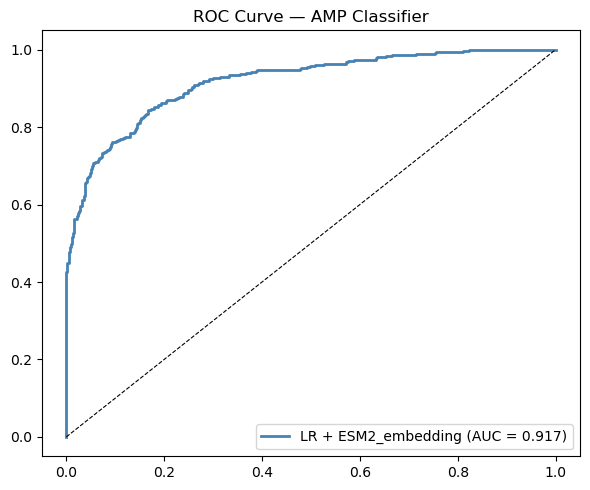

In [24]:
all_idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    all_idx, test_size=0.2, random_state=42, stratify=y)

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

clf    = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))

fpr, tpr ,_ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"LR + ESM2_embedding (AUC = {roc_auc:.3f})")
ax.plot([0,1],[0,1],"k--", lw=0.8)
ax.set_title("ROC Curve — AMP Classifier")
ax.legend(loc="lower right")    
plt.tight_layout()
plt.savefig("../results/figures/01_roc_curve.png", dpi=150)
plt.show()


In [26]:
joblib.dump(clf, "../models/lr_classifier.pkl")
test_sequences = df["sequence"].values[test_idx]

np.save("../data/X_test.npy", X_test)
np.save("../data/y_test.npy", y_test)
np.save("../data/test_sequences.npy", test_sequences)
np.save("../data/test_idx.npy", test_idx)